# Spectrum Kernel GPR
- Trying to fix GPR performance by using a sum of SHOTerms to approximate the Gonzalez kernel
- If this is collapsing to boundaries again, try using the variance limitation with softmax.

- Writing a generalised function to fir the GPR using a spectrum kernal with K terms.
- Spectrum kernel here is a sum of SHO terms which, in the underdamped Q>0.5 regime, is equivalent to a sum of K quasi-normal terms.
- Each SHO has:
    - Magnitude defined by the sigma.
    - Period defined by rho.
    - Quality factor Q defining the exp decay rate; constrained to > 0.5 for underdamped regime.

In [14]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable


# Importing data
data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')


# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.6, valid_split=0.39):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

train_df, valid_df, test_df = split_df(data)
print(train_df.shape, valid_df.shape, test_df.shape)


def plot_predictions(trainingset, validset, results):
    fig, ax = plt.subplots(figsize=(20, 5))
    ax.plot(trainingset['year'], trainingset['sind'], color='blue', label='Training')
    ax.plot(validset['year'], validset['sind'], color='orange', label='Actual')
    results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(results_time, results['forecast'], color='green', label='Predictions')
    ax.fill_between(results_time, results['lower'], results['upper'], color='green', alpha=0.2, label='Uncertainties')
    plt.legend()
    plt.show()

train_mean = train_df["sind"].mean()
train_std  = train_df["sind"].std()


error_percent = 5
train_yerr = train_df['sind'] * error_percent / 100

(3809, 3) (2476, 3) (63, 3)


C:\Users\Joey\AppData\Local\Temp\ipykernel_18676\3289844157.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)


True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
+---------------+----------------+--------------+
|     sigma     |      rho       |      Q       |
+---------------+----------------+--------------+
| 0.001 to 0.03 | 0.10 to 150.00 | 0.50 to 3.00 |
|     0.001     |      2.15      |     1.83     |
|     0.001     |     10.21      |     3.00     |
|     0.001     |     10.21      |     3.00     |
|     0.002     |     10.21      |     3.00     |
|     0.003     |     10.21      |     3.00     |
+---------------+----------------+--------------+


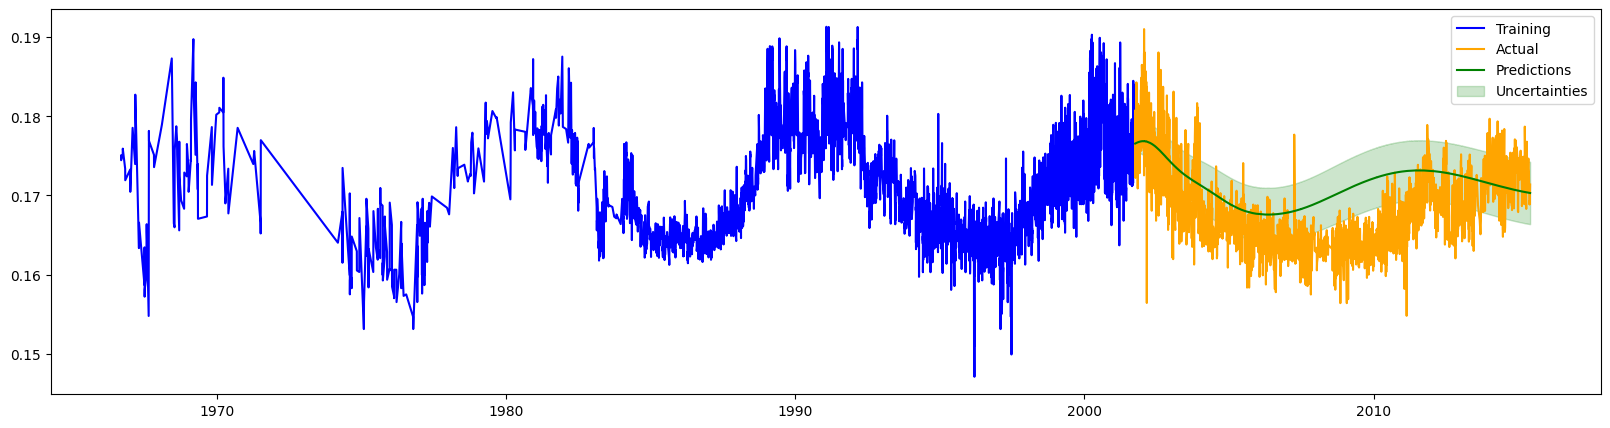

In [35]:
def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def fit_spec_gpr(k=2, plot = True):
    '''
    k is at minimum 1
    '''
    # Create the initial conditions as required by the k value
    sigma_0s = [train_std/k for k_idx in range(k)]
    rho_0s = [np.random.uniform(1,120) for k_idx in range(k)]
    q_0s = [np.random.uniform(0.5,3) for k_idx in range(k)]
    # Take the log to create initial guesses
    initial_guess = np.concatenate([np.log(sigma_0s), np.log(rho_0s), np.log(q_0s)])
    # Create the bounds
    sigma_upper = 5 * train_std
    sigma_bounds = [(np.log(0.001), np.log(sigma_upper)) for k_idx in range(k)]
    rho_bounds = [(np.log(0.1), np.log(150)) for k_idx in range(k)]
    q_bounds = [(np.log(0.5),np.log(3)) for k_idx in range(k)]
    bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])
    # Create the initial kernel
    kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
    for k_idx in range(1,k):
        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])
    # Define the gp
    gp = celerite2.GaussianProcess(kernel, mean=train_mean)
    gp.compute(train_df['year'], yerr=train_yerr)
    # Train the gp
    gp_res = minimize(NLL, initial_guess, args=(gp, k,train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
    gp = set_params(gp_res.x, k, gp)
    gp.recompute()
    # Print the opt results
    best = np.exp(gp_res.x)
    # blo = np.exp([b[0] for b in bounds])
    # bhi = np.exp([b[1] for b in bounds])
    print(gp_res.success, gp_res.message)
    table = PrettyTable(["sigma", "rho", "Q"])
    table.add_row([f"{np.exp(sigma_bounds[0][0]):.3f} to {np.exp(sigma_bounds[0][1]):.2f}",
                            f"{np.exp(rho_bounds[0][0]):.2f} to {np.exp(rho_bounds[0][1]):.2f}",
                            f"{np.exp(q_bounds[0][0]):.2f} to {np.exp(q_bounds[0][1]):.2f}"
                   ])
    best_sigmas = best[0:k]
    best_rhos = best[k:2*k]
    best_qs = best[2*k:]

    for k_idx in range(k):
        table.add_row([f"{best_sigmas[k_idx]:.3f}", f"{best_rhos[k_idx]:.2f}", f"{best_qs[k_idx]:.2f}"])
    
    print(table)
    
    # Predict forewards
    t_pred = valid_df['year']
    mu, cov = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
    sigma = np.sqrt(cov)
    # Plot
    if plot:
        results = pd.DataFrame({
        'forecast' : mu,
        'lower'    : mu - sigma,
        'upper'    : mu + sigma,
        }, index=valid_df.index)

        plot_predictions(
        trainingset=train_df,
        validset=valid_df,
        results=results)
    

fit_spec_gpr(k=5,plot=True)
